In [22]:
import numpy as np
import matplotlib.pyplot as pyplot
import os
from ransac_benchmark_imc.io import load_h5





In [23]:
import re
from collections import defaultdict

def nested_dict():
    """Helper to create arbitrarily deep nested dictionaries."""
    return defaultdict(nested_dict)

def parse_prosac_dirs(dirnames):
    """
    Parses a list of dirname strings like:
    '_PROSAC-False_conf-0.99_inl_th-0.5_match_th-0.7_maxiter-1000'
    and returns a nested dict:
    D[inl_th][match_th][conf][max_iter] = original_string
    """
    pattern = re.compile(
        r"_PROSAC-(?P<PROSAC>[^_]+)_conf-(?P<conf>[^_]+)_inl_th-(?P<inl_th>[^_]+)_match_th-(?P<match_th>[^_]+)_maxiter-(?P<max_iter>[^_]+)"
    )
    
    D = nested_dict()
    
    for s in dirnames:
        m = pattern.match(s)
        if not m:
            continue  # skip malformed strings
        conf = m.group("conf")
        prosac = m.group("PROSAC")
        inl_th = m.group("inl_th")
        match_th = m.group("match_th")
        max_iter = m.group("max_iter")
        D[prosac][inl_th][match_th][conf][max_iter] = s
    
    return D


In [20]:
#!ls ../results/val/f/poselib

'../results/test/f/cv2f-gc'

In [34]:
dict_for_plotting = {}
results_root_dir = '../results/test/f/'
methods = [x for x in os.listdir(results_root_dir)]


for method in methods:
    cur_method_dir = os.path.join(results_root_dir, method)
    dirs = os.listdir(cur_method_dir)
    parsed = parse_prosac_dirs(dirs)
    print (f'{parsed.keys()=}')
    for prosac, v0 in parsed.items():
        cur_dict_for_plotting = {}
        cur_dict_for_plotting['name'] = method
        prosac = True if prosac=='True' else False
        cur_dict_for_plotting['PROSAC'] =prosac
        for inl_th, v in v0.items():
            cur_dict_for_plotting['inl_th'] = inl_th
            for m_th, vv in v.items():
                cur_dict_for_plotting['snn_th'] = m_th
                for conf, vvv in vv.items():
                    cur_dict_for_plotting[float(conf)] = {}
                    for max_iters, dirname in vvv.items():
                        try:
                            pp = os.path.join(cur_method_dir, dirname, 'maa_FINAL.h5')
                            res = load_h5(pp)#['mAA']
                        except:
                            print (f'{pp} is missing')
                            continue
                        cur_dict_for_plotting[float(conf)][int(max_iters)] = res
        key1 = f'{method}'
        if prosac:
            key1 += ' PROSAC'
        print (f"{key1=}")
        dict_for_plotting[key1] = cur_dict_for_plotting
                

parsed.keys()=dict_keys(['False'])
key1='sklearn-7pt-numba'
parsed.keys()=dict_keys(['False'])
key1='bansac-loransac'
parsed.keys()=dict_keys(['False'])
key1='sklearn-7pt'
parsed.keys()=dict_keys(['False'])
key1='poselib'
parsed.keys()=dict_keys(['False'])
key1='pyransac'
parsed.keys()=dict_keys(['False'])
key1='pygcransac'
parsed.keys()=dict_keys(['False'])
key1='sklearn-8pt'
parsed.keys()=dict_keys(['False'])
key1='bansac'
parsed.keys()=dict_keys(['False'])
key1='vibesac'
parsed.keys()=dict_keys(['False'])
key1='cv2f-magsac'


In [30]:
#dict_for_plotting

In [25]:
import matplotlib.pyplot as plt
import matplotlib

def get_plot_defaults():
    return {
        'font_size_title': 32,
        'font_size_axes': 25,
        'font_size_ticks': 22,
        'font_size_legend': 22,
        'line_width': 3,
        'marker_size': 10,
        'dpi': 600,
    }

def make_like_colab(fig, ax):
    # use a gray background
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#E6E6E6')
    
    # draw solid white grid lines
    ax.grid(color='white', linestyle='solid')

    # hide axis spines
    for spine in ax.spines.values():
        spine.set_visible(False)


    # remove the notch on the ticks (but show the label)
    ax.tick_params(axis=u'both', which=u'both', length=0)
cmap = matplotlib.cm.get_cmap('tab20')
defaults = get_plot_defaults()
    

/var/tmp/ipykernel_3511337/2974264131.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('tab20')


In [26]:
dict_for_plotting

{'sklearn-7pt-numba': {'name': 'sklearn-7pt-numba',
  'PROSAC': False,
  'inl_th': '0.5',
  'snn_th': '0.8',
  0.9999: {2000: {'mAA': 0.34054095, 'time': 0.46132331226811263},
   200: {'mAA': 0.30313355, 'time': 0.13077832717732785},
   1000: {'mAA': 0.3349787, 'time': 0.32820723354348164},
   500: {'mAA': 0.3244961, 'time': 0.22828305257996492},
   100: {'mAA': 0.27234566, 'time': 0.07849604794454544},
   5000: {'mAA': 0.34181368, 'time': 0.6976918789233666}},
  0.99: {5000: {'mAA': 0.32304376, 'time': 0.5188844877967713},
   2000: {'mAA': 0.32008982, 'time': 0.3565935832424681},
   200: {'mAA': 0.29649386, 'time': 0.11147566290628728},
   500: {'mAA': 0.31213692, 'time': 0.18410872783315368},
   100: {'mAA': 0.26847813, 'time': 0.07137886730617476},
   1000: {'mAA': 0.3179663, 'time': 0.2589993224922028}}},
 'bansac-loransac': {'name': 'bansac-loransac',
  'PROSAC': False,
  'inl_th': '0.5',
  'snn_th': '0.85',
  0.9999: {200: {'mAA': 0.4042514, 'time': 0.0041398544076257345},
   100

In [27]:
for a in dict_for_plotting.keys():
    print (a)

sklearn-7pt-numba
bansac-loransac
sklearn-7pt
poselib
pyransac
pygcransac
sklearn-8pt
bansac
vibesac
cv2f-magsac


In [ ]:
color_dict = {
    'poselib': cmap(0),
    'pycolmap': cmap(1),
    
    'pygcransac': cmap(2),
    'sklearn-8pt': cmap(3),
    'sklearn-7pt': cmap(4),
    'sklearn-7pt-numba': cmap(5),
    'kornia-cpu': cmap(6),
    'numba-loransac-vibesac-old': cmap(7),
    'numba-loransac-vibesac': cmap(8),

    'vibesac': cmap(10),

    'degensac': cmap(11),
    'pyransac': cmap(19),
    'cv2f-ransac': cmap(12),
    'cv2f-magsac': cmap(13),
    'cv2f-gc': cmap(14),
    'bansac-loransac': cmap(15),

  
    'pymagsac': cmap(16),
    'pygcransac': cmap(17),

    'superansac': cmap(18),
}

/var/tmp/ipykernel_3511337/1579731656.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('tab20')


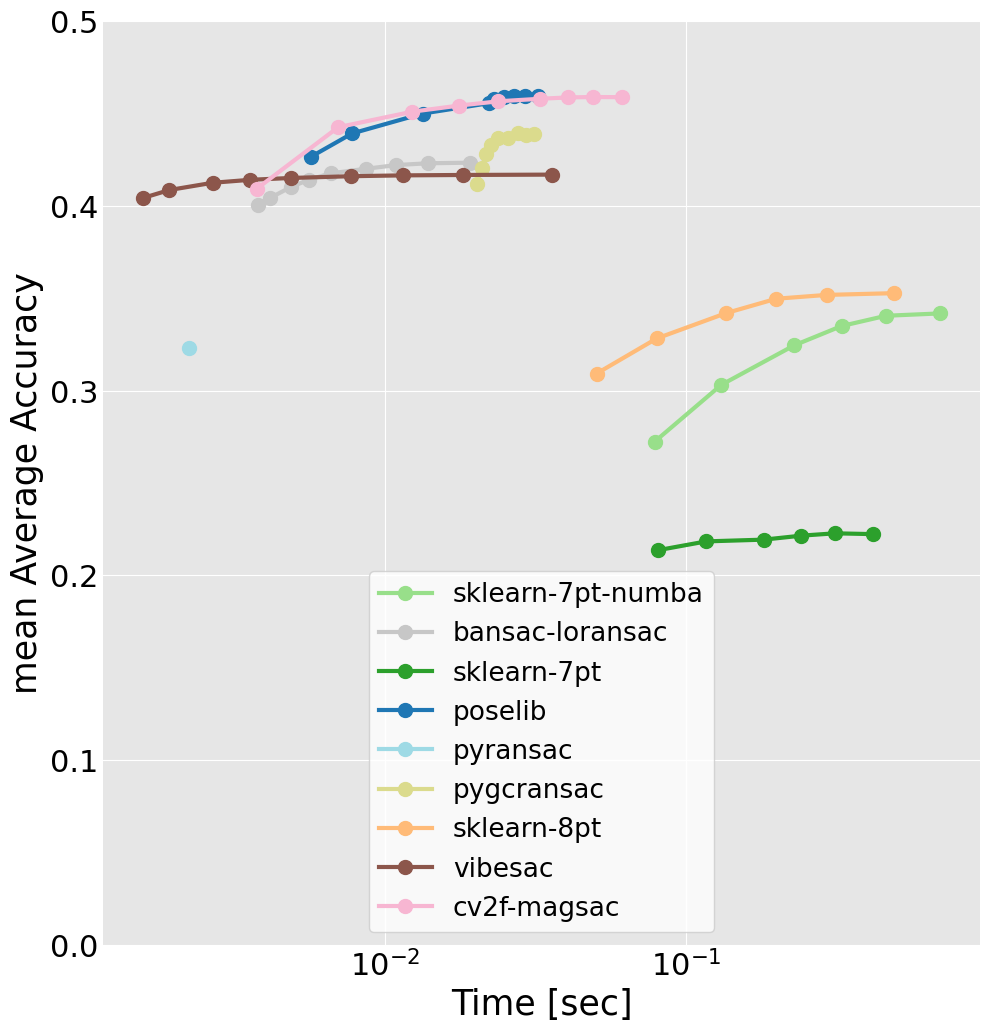

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10,12))
cmap = matplotlib.cm.get_cmap('tab20')

ignore_list = ['bansac']
i = 0

for m_name, v0 in dict_for_plotting.items():
    #if 'superansac' not in m_name:
    #    continue
    if m_name in ignore_list:
        continue
    basename = m_name.split(' ')[0]
    for conf, conf_res in v0.items():
        if conf in ['inl_th', 'snn_th', 'name', 'PROSAC']:
            continue
        if conf!=0.9999:
            continue
        maxiters = []
        maas = []
        times = []
        for max_iter, res in conf_res.items():
            maxiters.append(max_iter)
            try:
                if res['mAA']==0:
                    continue
            except:
                continue
            try:
                times.append(res['time'])
                maas.append(res['mAA'])
            except:
                continue
        if len(maas) == 0:
            continue
        if len(maas)!=len(maxiters):
            continue
        idxs = np.argsort(maxiters)
        maas = np.array(maas)[idxs]
        times = np.array(times)[idxs]
        maxiters = np.array(maxiters)[idxs]
        ax.semilogx(times, maas,
                    '-x' if 'PROSAC' in m_name else '-o',
                    label=f'{m_name}',
                    linewidth=defaults['line_width'], 
                    markersize=defaults['marker_size'],
                    color=color_dict[basename])
    i += 1
ax.legend()
ax.set_ylim(0, 0.5)

ax.set_ylabel('mean Average Accuracy', fontsize=defaults['font_size_axes'])
ax.set_xlabel('Time [sec]', fontsize=defaults['font_size_axes'])
ax.xaxis.set_tick_params(labelsize=defaults['font_size_ticks'])
ax.yaxis.set_tick_params(labelsize=defaults['font_size_ticks'])


ax.set_ylim(0, .5)
make_like_colab(fig, ax)
ax.legend( prop={'size': defaults['font_size_legend'] - 3}, loc='lower center', ncol=1)
fig.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.15)
        
plt.savefig('ransac-conf-0.99.pdf', bbox_inches='tight', dpi=defaults['dpi'])


/var/tmp/ipykernel_2560210/1477437516.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('tab20')


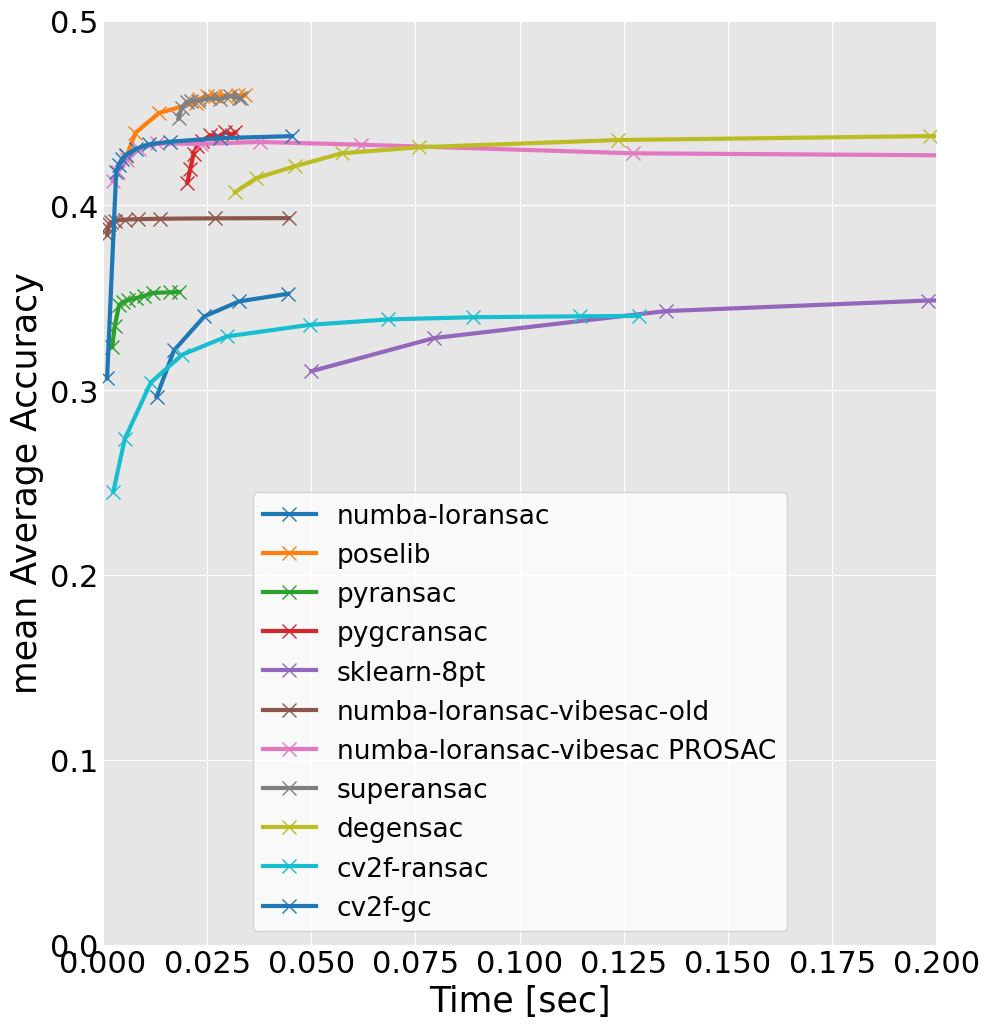

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10,12))
cmap = matplotlib.cm.get_cmap('tab20')

ignore_list = ['pymagsac']
for m_name, v0 in dict_for_plotting.items():
    if m_name in ignore_list:
        continue
    #if m_name!='degensac':
    #    continue
    prosac = False if v0['PROSAC']=='False' else True
    for conf, conf_res in v0.items():
        if conf in ['inl_th', 'snn_th', 'name', 'PROSAC']:
            continue
        if conf!=0.9999:
            continue
        maxiters = []
        maas = []
        times = []
        for max_iter, res in conf_res.items():
            maxiters.append(max_iter)
            try:
                if res['mAA']==0:
                    continue
            except:
                continue
            try:
                times.append(res['time'])
                maas.append(res['mAA'])
            except:
                continue
        if len(maas) == 0:
            continue
        if len(maas)!=len(maxiters):
            continue
        idxs = np.argsort(maxiters)
        maas = np.array(maas)[idxs]
        times = np.array(times)[idxs]
        maxiters = np.array(maxiters)[idxs]
        ax.plot(times, maas, '-x', label=f'{m_name} PROSAC' if prosac else f'{m_name}', linewidth=defaults['line_width'], 
                    markersize=defaults['marker_size'] )
ax.legend()
ax.set_ylim(0, 0.5)
ax.set_xlim(0, 0.2)

ax.set_ylabel('mean Average Accuracy', fontsize=defaults['font_size_axes'])
ax.set_xlabel('Time [sec]', fontsize=defaults['font_size_axes'])
ax.xaxis.set_tick_params(labelsize=defaults['font_size_ticks'])
ax.yaxis.set_tick_params(labelsize=defaults['font_size_ticks'])


ax.set_ylim(0, .5)
make_like_colab(fig, ax)
ax.legend( prop={'size': defaults['font_size_legend'] - 3}, loc='lower center', ncol=1)
fig.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.15)
        
plt.savefig('ransac-conf-0.99-linf.pdf', bbox_inches='tight', dpi=defaults['dpi'])


/var/tmp/ipykernel_2560210/1701379322.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('tab20')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


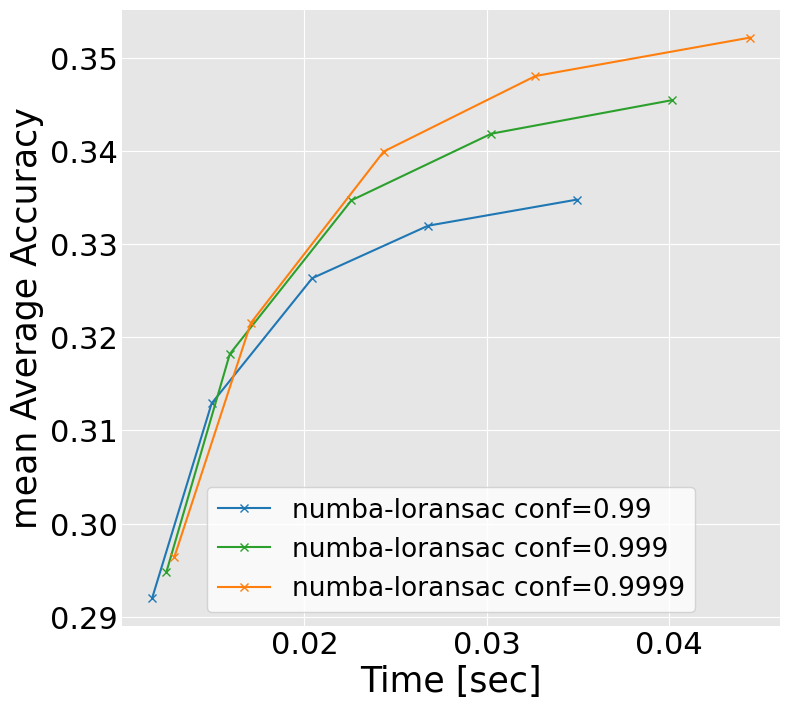

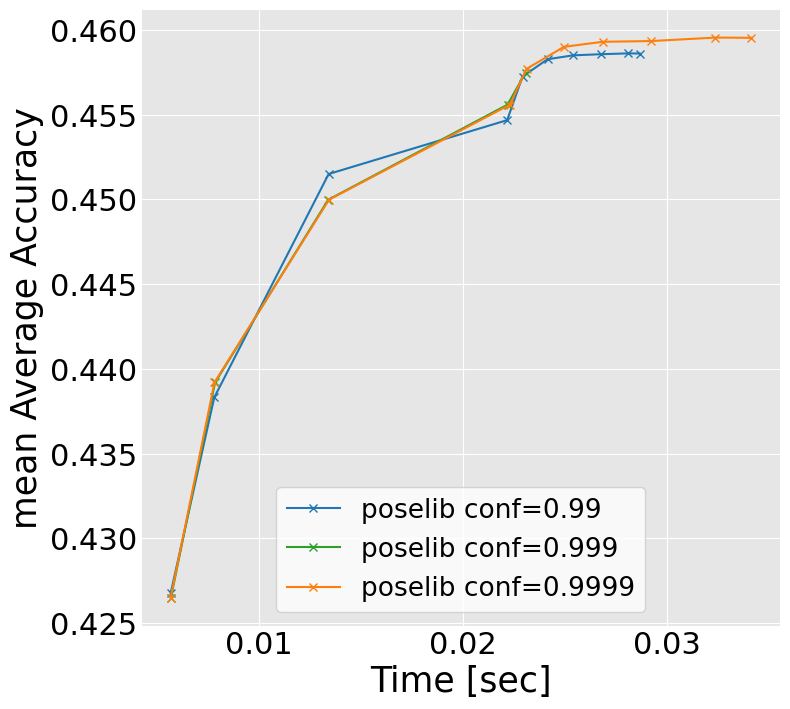

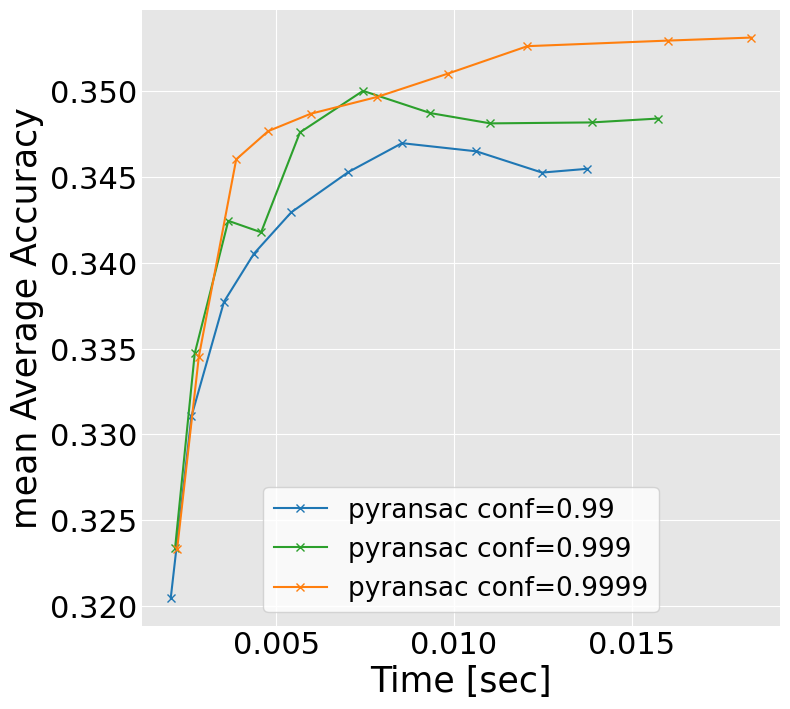

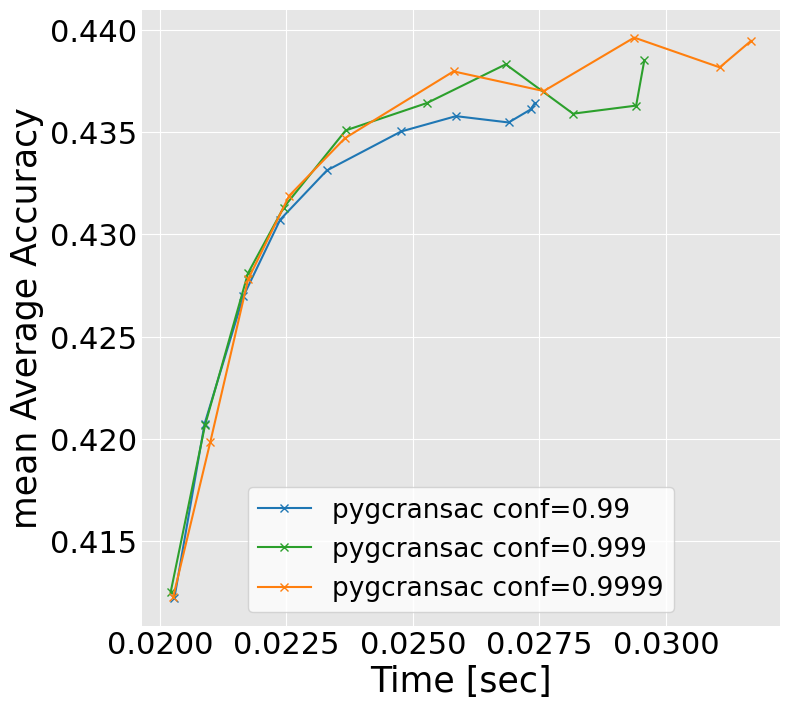

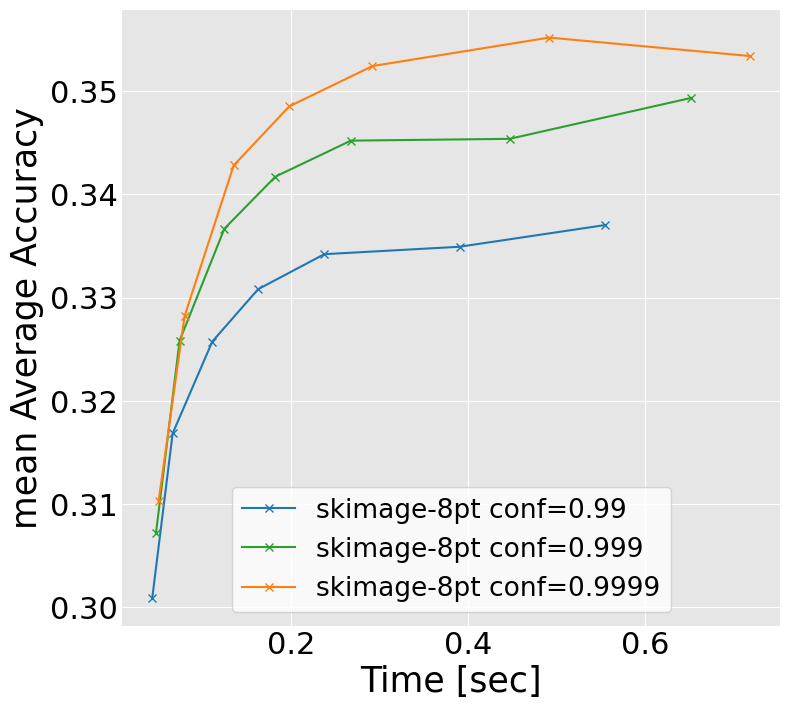

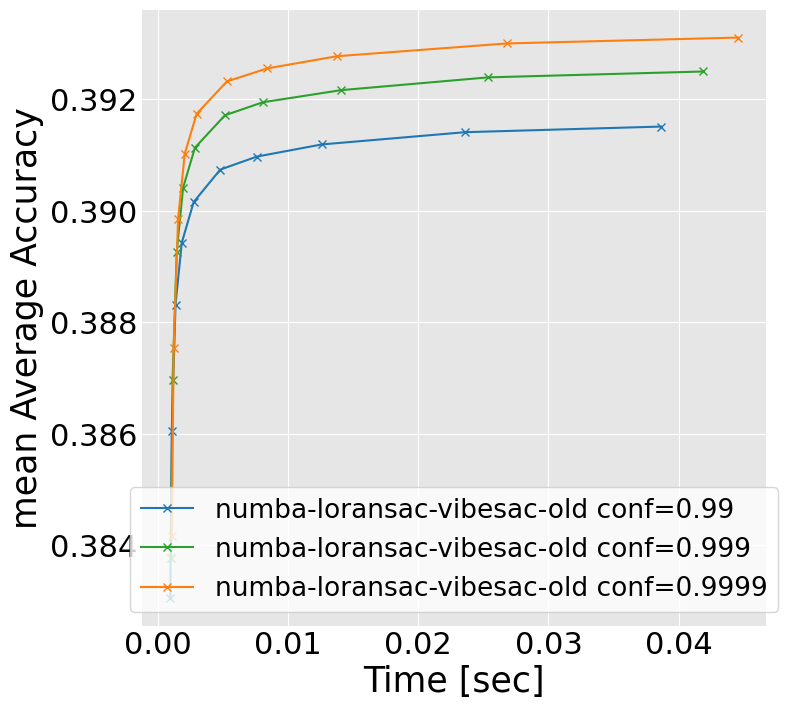

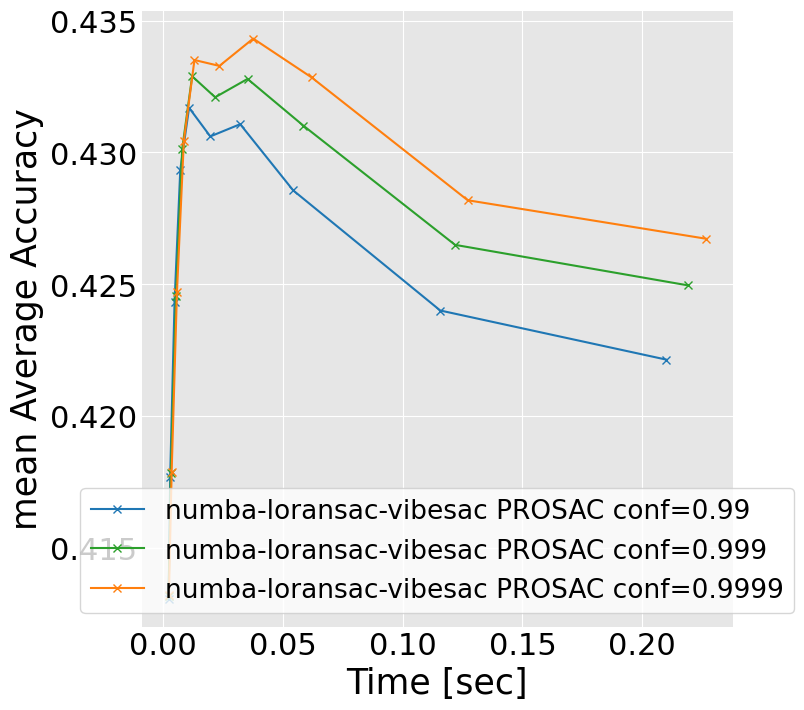

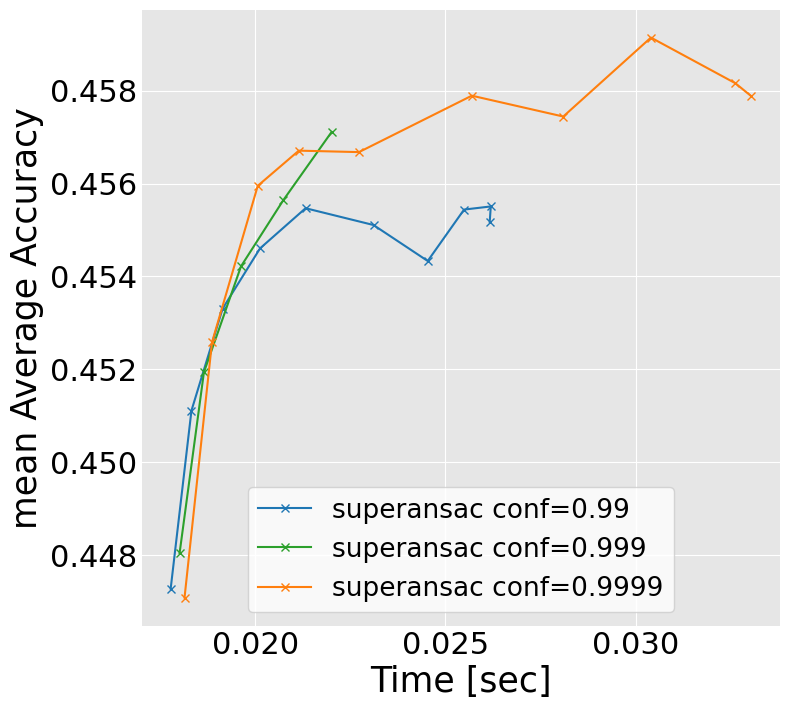

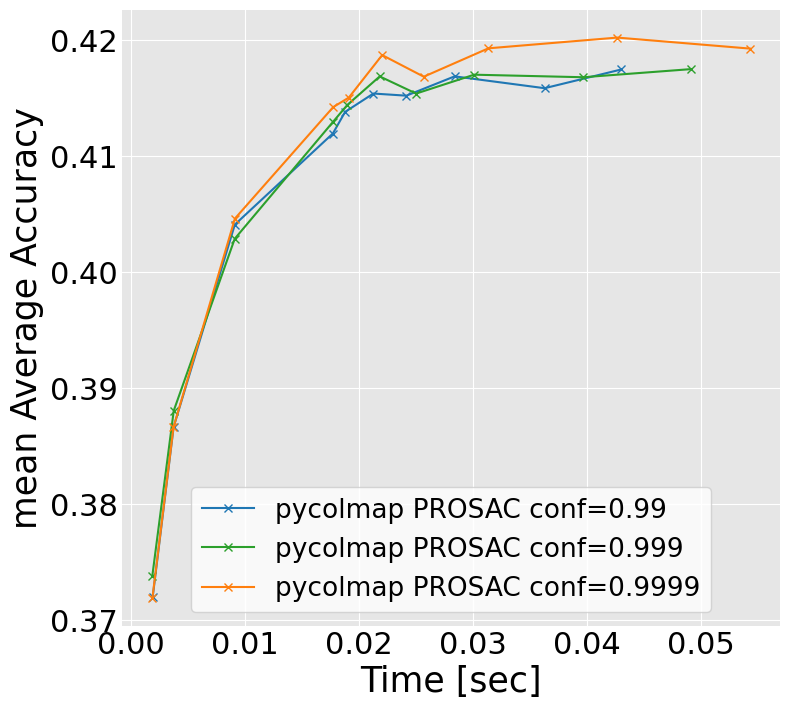

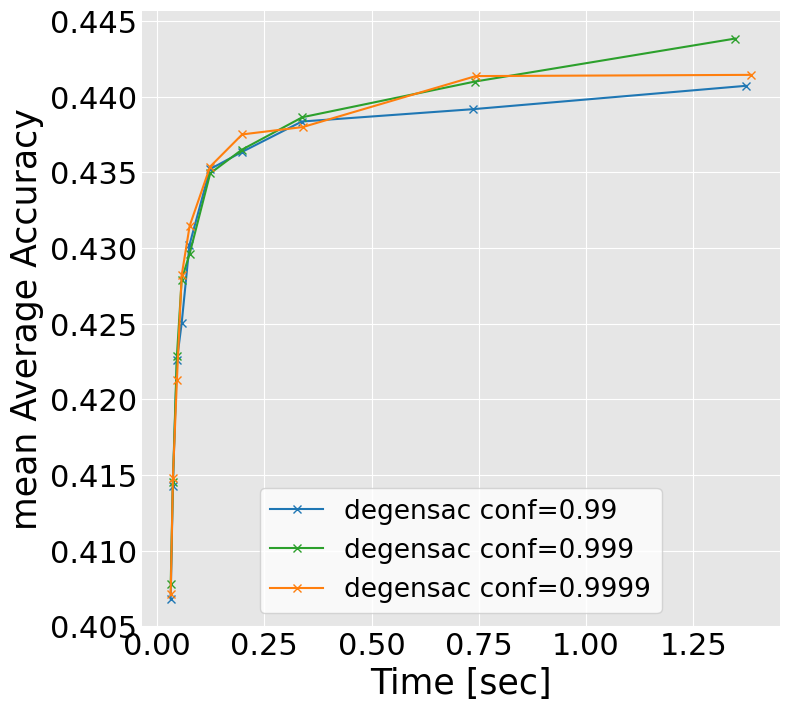

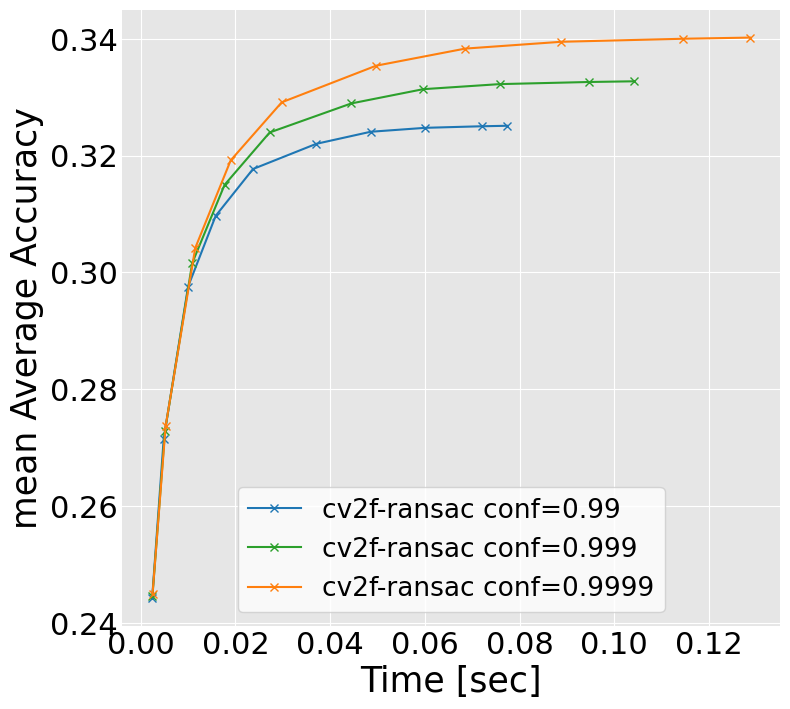

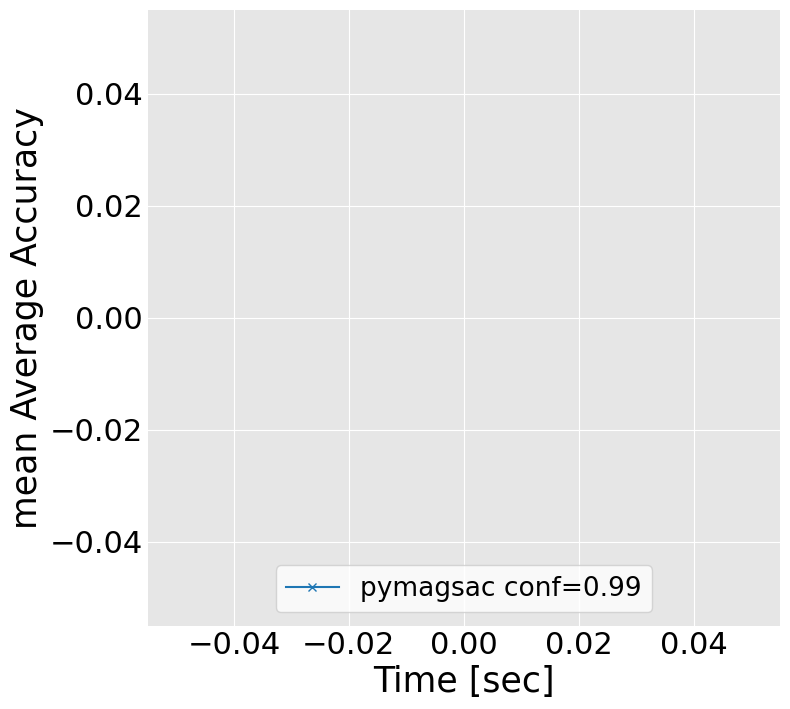

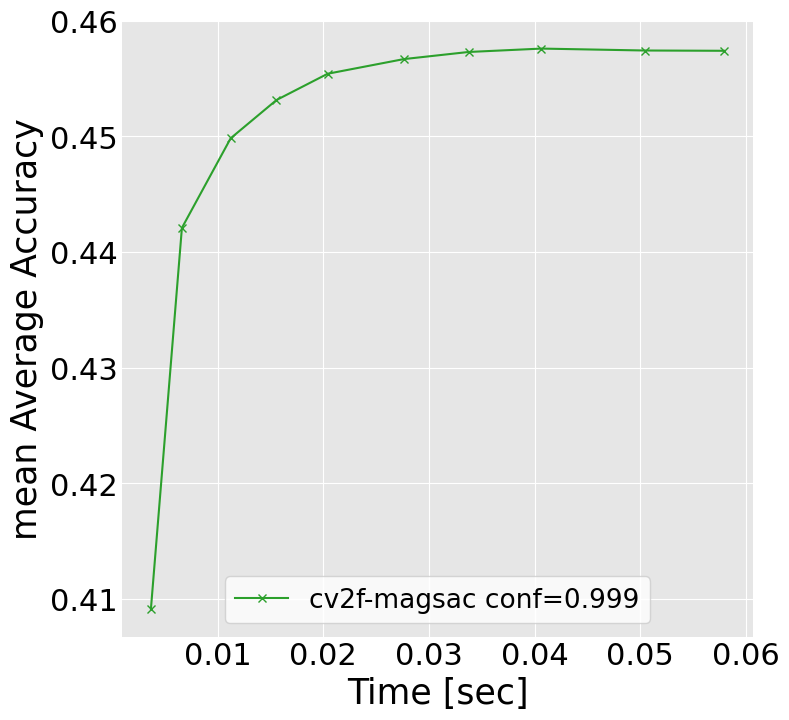

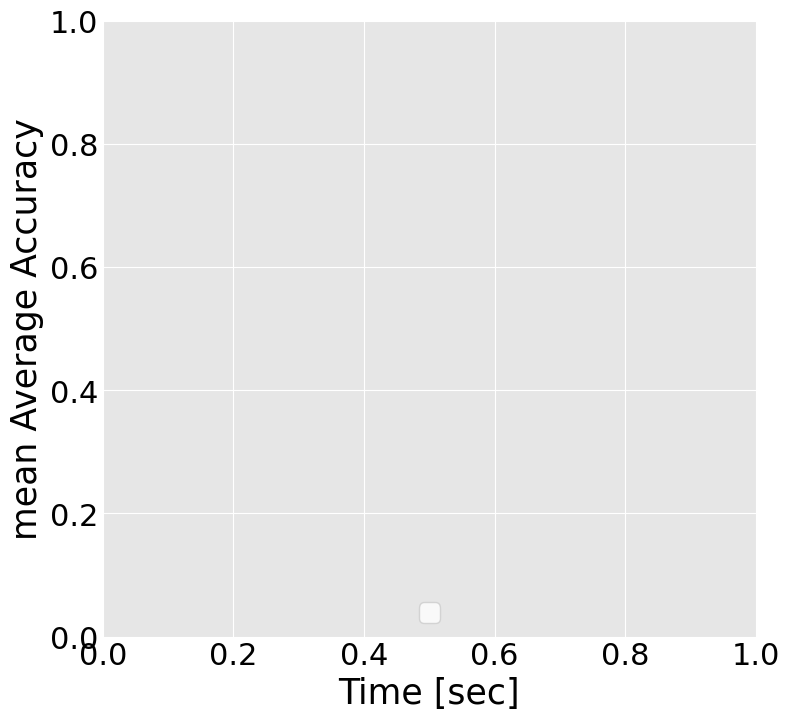

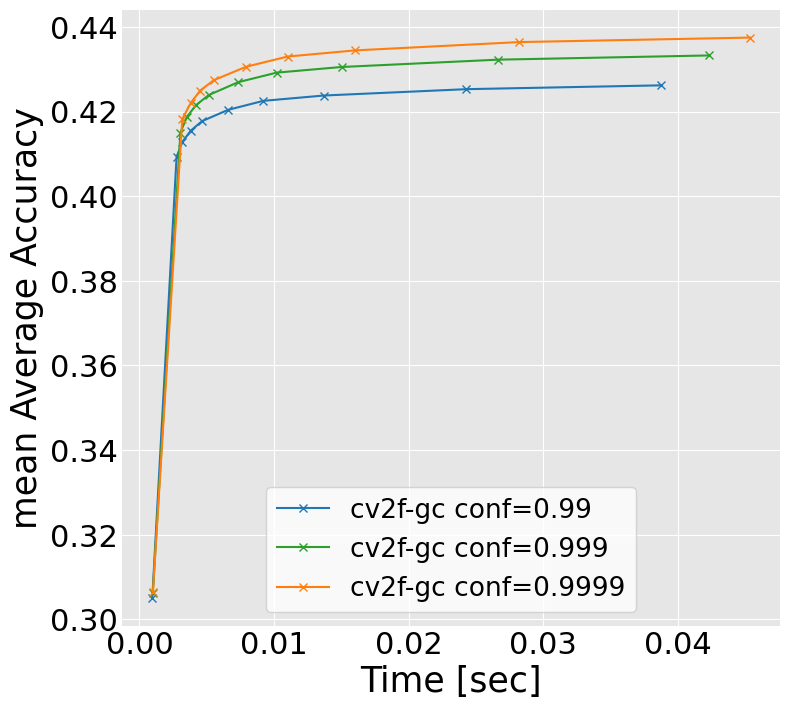

In [34]:
import matplotlib.pyplot as plt

conf_color_dict = {0.99: cmap(0), 0.999: cmap(4), 0.9999: cmap(2)}
for m_name, v in dict_for_plotting.items():
    #if m_name!='degensac':
    #    continue
    fig, ax = plt.subplots(1, 1, figsize=(8,8))
    cmap = matplotlib.cm.get_cmap('tab20')
    for conf in [0.99, 0.999, 0.9999]:
        try:
            conf_res = v[conf]
        except:
            continue
        maxiters = []
        maas = []
        times = []
        for max_iter, res in conf_res.items():
            maxiters.append(max_iter)
            try:
                if res['mAA']==0:
                    continue
            except:
                continue
            try:
                times.append(res['time'])
                maas.append(res['mAA'])
            except:
                continue
        if len(maas) == 0:
            continue
        if len(maas)!=len(maxiters):
            continue
        idxs = np.argsort(maxiters)
        maas = np.array(maas)[idxs]
        times = np.array(times)[idxs]
        maxiters = np.array(maxiters)[idxs]
        ax.plot(times, maas, '-x', label=f'{m_name.replace("sklearn", "skimage")} conf={conf}', color=conf_color_dict[conf] )
    ax.legend()
    ax.set_ylabel('mean Average Accuracy', fontsize=defaults['font_size_axes'])
    ax.set_xlabel('Time [sec]', fontsize=defaults['font_size_axes'])
    ax.xaxis.set_tick_params(labelsize=defaults['font_size_ticks'])
    ax.yaxis.set_tick_params(labelsize=defaults['font_size_ticks'])
    #ax.set_ylim(0.3, .5)
    make_like_colab(fig, ax)
    ax.legend( prop={'size': defaults['font_size_legend'] - 3}, loc='lower center', ncol=1)
    fig.tight_layout()
    plt.subplots_adjust(top=0.92, bottom=0.15)


        
        